# ACL Recovery Analytics

## Objective

This notebook develops an interpretable participant-level analytics framework
using bilateral sEMG features generated from the signal-processing pipeline.

Rather than treating ACL recovery as a simple ACL-vs-healthy classification
problem, the analysis focuses on individual activation patterns relative to a
healthy reference distribution.

The framework evaluates three dimensions:

1. **Activation direction** — whether involved-side activation is lower or higher
   than the uninvolved side.
2. **Asymmetry magnitude** — how strongly bilateral activation differs.
3. **Reference position** — how the participant compares with QC-valid healthy
   controls.

The resulting participant profiles are intended as exploratory analytics
outputs rather than clinical diagnostic or return-to-sport criteria.

In [1]:
# Cell 2: Import libraries

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cell 3: Load processed participant-level features

DATA_PATH = Path("../data/processed/bilateral_semg_features.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (22, 17)


,Cohort,Participant,Involved_RMS,Uninvolved_RMS,RMS_Ratio,Symmetry_Deviation,Involved_Valid_Contractions,Uninvolved_Valid_Contractions,Involved_Active_Fraction,Uninvolved_Active_Fraction,Activation_Difference_Pct,Activation_Direction,Robust_Asymmetry_Score,Asymmetry_Category,Involved_QC_Status,Uninvolved_QC_Status,Primary_Analysis
0,ACL Patient,patient1,0.000154,0.000253,0.610105,0.494124,9,9,0.387989,0.375439,38.989485,Involved side lower,3.471508,Highly elevated,Pass,Pass,True
1,ACL Patient,patient10,0.000181,0.000202,0.893173,0.112975,8,9,0.444040,0.421211,10.682671,Involved side lower,-1.454920,Within reference range,Pass,Pass,True
2,ACL Patient,patient11,0.000095,0.000164,0.582636,0.540193,9,9,0.468607,0.385836,41.736444,Involved side lower,4.066965,Highly elevated,Pass,Pass,True
3,ACL Patient,patient12,0.000052,0.000117,0.449514,0.799587,5,9,0.305496,0.359225,55.048551,Involved side lower,7.419680,Highly elevated,Review - low contraction count,Pass,False
4,ACL Patient,patient2,0.000065,0.000081,0.801447,0.221336,9,8,0.316977,0.405487,19.855263,Involved side lower,-0.054329,Within reference range,Pass,Pass,True


In [3]:
# Cell 4: Validate processed input

print("Participants by cohort:")
print(df["Cohort"].value_counts())

print("\nPrimary-analysis participants:")
print(
    df[df["Primary_Analysis"] == True]
    ["Cohort"]
    .value_counts()
)

print("\nQC issues:")
display(
    df[
        df["Primary_Analysis"] == False
    ][
        [
            "Participant",
            "Cohort",
            "Involved_QC_Status",
            "Uninvolved_QC_Status"
        ]
    ]
)

Participants by cohort:
Cohort
ACL Patient        12
Healthy Control    10
Name: count, dtype: int64

Primary-analysis participants:
Cohort
ACL Patient        11
Healthy Control     8
Name: count, dtype: int64

QC issues:


,Participant,Cohort,Involved_QC_Status,Uninvolved_QC_Status
3,patient12,ACL Patient,Review - low contraction count,Pass
20,healthy8,Healthy Control,Pass,Exclude - no valid contractions
21,healthy9,Healthy Control,Pass,Review - amplitude outlier


In [4]:
# Cell 5: Create QC-valid analysis dataset

analysis_df = df[
    df["Primary_Analysis"] == True
].copy()

acl_df = analysis_df[
    analysis_df["Cohort"] == "ACL Patient"
].copy()

healthy_df = analysis_df[
    analysis_df["Cohort"] == "Healthy Control"
].copy()


print("Analysis dataset:", analysis_df.shape)
print("ACL participants:", len(acl_df))
print("Healthy controls:", len(healthy_df))

Analysis dataset: (19, 17)
ACL participants: 11
Healthy controls: 8


In [5]:
# Cell 6: Build healthy reference profile

healthy_reference = {
    "N": len(healthy_df),

    "Median_Symmetry_Deviation":
        healthy_df["Symmetry_Deviation"].median(),

    "MAD_Symmetry_Deviation":
        np.median(
            np.abs(
                healthy_df["Symmetry_Deviation"]
                - healthy_df["Symmetry_Deviation"].median()
            )
        ),

    "Median_RMS_Ratio":
        healthy_df["RMS_Ratio"].median(),

    "Median_Involved_Active_Fraction":
        healthy_df["Involved_Active_Fraction"].median(),

    "Median_Uninvolved_Active_Fraction":
        healthy_df["Uninvolved_Active_Fraction"].median()
}

healthy_reference_table = pd.DataFrame(
    healthy_reference.items(),
    columns=["Metric", "Value"]
)

display(healthy_reference_table)

,Metric,Value
0,N,8.000000
1,Median_Symmetry_Deviation,0.225539
2,MAD_Symmetry_Deviation,0.077368
3,Median_RMS_Ratio,0.818165
4,Median_Involved_Active_Fraction,0.422206
5,Median_Uninvolved_Active_Fraction,0.379278


In [23]:
# Cell 7: Create participant assessment function

def assess_participant(participant_id, data, reference):

    participant = data[
        data["Participant"] == participant_id
    ]

    if len(participant) == 0:
        raise ValueError(
            f"Participant '{participant_id}' not found."
        )

    row = participant.iloc[0]

    # Do not generate an assessment for recordings
    # that failed primary QC.
    if not row["Primary_Analysis"]:
        return {
            "Participant": participant_id,
            "Assessment_Status": "QC review required",
            "Involved_QC": row["Involved_QC_Status"],
            "Uninvolved_QC": row["Uninvolved_QC_Status"]
        }

    ratio = row["RMS_Ratio"]
    deviation = row["Symmetry_Deviation"]

    healthy_median = reference[
        "Median_Symmetry_Deviation"
    ]

    healthy_mad = reference[
        "MAD_Symmetry_Deviation"
    ]

    robust_score = (
        deviation - healthy_median
    ) / healthy_mad

    # Direction
    if ratio < 0.90:
        direction = "Involved side lower"

    elif ratio > 1.10:
        direction = "Involved side higher"

    else:
        direction = "Approximately symmetric"

    # Exploratory reference category
    if robust_score > 2:
        category = "Highly elevated"

    elif robust_score > 1:
        category = "Moderately elevated"

    else:
        category = "Within reference range"

    return {
    "Participant": participant_id,
    "Assessment_Status": "Available",

    "Involved_RMS": row["Involved_RMS"],
    "Uninvolved_RMS": row["Uninvolved_RMS"],

    "RMS_Ratio": ratio,
    "Activation_Difference_Pct":
        abs(ratio - 1) * 100,
    "Activation_Direction": direction,
    "Symmetry_Deviation": deviation,
    "Robust_Asymmetry_Score": robust_score,
    "Reference_Category": category,
    "Involved_Contractions":
        row["Involved_Valid_Contractions"],
    "Uninvolved_Contractions":
        row["Uninvolved_Valid_Contractions"]
    }

In [24]:
# Cell 8: Test participant assessment

patient1_assessment = assess_participant(
    "patient1",
    df,
    healthy_reference
)

patient1_assessment

{'Participant': 'patient1',
 'Assessment_Status': 'Available',
 'Involved_RMS': 0.0001543706793409,
 'Uninvolved_RMS': 0.0002530230737405,
 'RMS_Ratio': 0.6101051459804384,
 'Activation_Difference_Pct': 38.98948540195616,
 'Activation_Direction': 'Involved side lower',
 'Symmetry_Deviation': 0.4941239662091258,
 'Robust_Asymmetry_Score': 3.4715084224366346,
 'Reference_Category': 'Highly elevated',
 'Involved_Contractions': 9,
 'Uninvolved_Contractions': 9}

In [25]:
# Cell 9: Test QC-aware assessment

patient12_assessment = assess_participant(
    "patient12",
    df,
    healthy_reference
)

patient12_assessment

{'Participant': 'patient12',
 'Assessment_Status': 'QC review required',
 'Involved_QC': 'Review - low contraction count',
 'Uninvolved_QC': 'Pass'}

In [26]:
# Cell 10: Convert participant assessment into a readable profile table

def assessment_to_table(assessment):

    if assessment["Assessment_Status"] != "Available":

        return pd.DataFrame({
            "Metric": [
                "Participant",
                "Assessment Status",
                "Involved QC",
                "Uninvolved QC"
            ],
            "Value": [
                assessment["Participant"],
                assessment["Assessment_Status"],
                assessment["Involved_QC"],
                assessment["Uninvolved_QC"]
            ]
        })

    return pd.DataFrame({
        "Metric": [
            "Participant",
            "Assessment Status",
            "RMS Ratio",
            "Activation Difference",
            "Activation Direction",
            "Symmetry Deviation",
            "Robust Asymmetry Score",
            "Reference Category",
            "Valid Involved Contractions",
            "Valid Uninvolved Contractions"
        ],
        "Value": [
            assessment["Participant"],
            assessment["Assessment_Status"],
            f'{assessment["RMS_Ratio"]:.3f}',
            f'{assessment["Activation_Difference_Pct"]:.1f}%',
            assessment["Activation_Direction"],
            f'{assessment["Symmetry_Deviation"]:.3f}',
            f'{assessment["Robust_Asymmetry_Score"]:.2f}',
            assessment["Reference_Category"],
            assessment["Involved_Contractions"],
            assessment["Uninvolved_Contractions"]
        ]
    })


patient1_table = assessment_to_table(
    patient1_assessment
)

display(patient1_table)

,Metric,Value
0,Participant,patient1
1,Assessment Status,Available
2,RMS Ratio,0.610
3,Activation Difference,39.0%
4,Activation Direction,Involved side lower
5,Symmetry Deviation,0.494
6,Robust Asymmetry Score,3.47
7,Reference Category,Highly elevated
8,Valid Involved Contractions,9
9,Valid Uninvolved Contractions,9


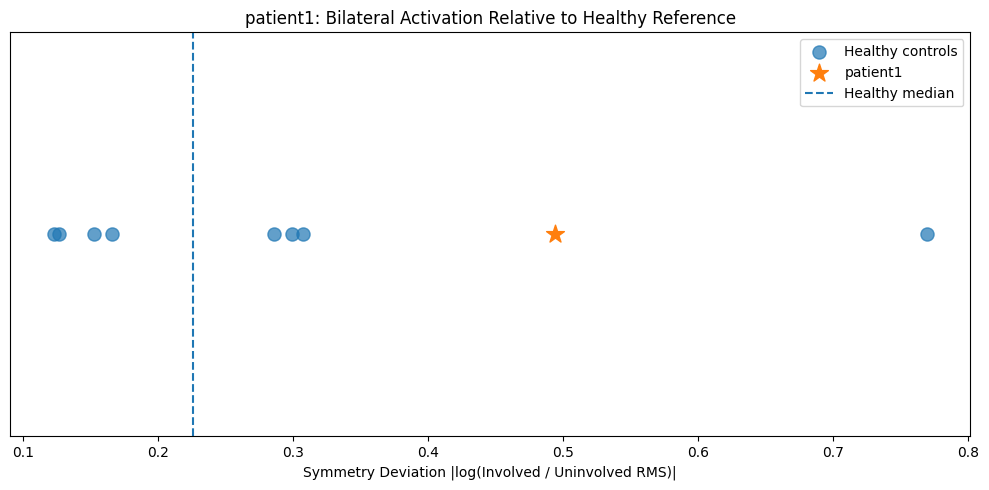

In [27]:
# Cell 11: Visualize participant asymmetry relative to healthy controls

participant_id = "patient1"

participant_row = analysis_df[
    analysis_df["Participant"] == participant_id
].iloc[0]

participant_deviation = participant_row["Symmetry_Deviation"]

healthy_values = healthy_df[
    "Symmetry_Deviation"
].dropna().to_numpy()


fig, ax = plt.subplots(figsize=(10, 5))

# Healthy controls
y_healthy = np.zeros(len(healthy_values))

ax.scatter(
    healthy_values,
    y_healthy,
    s=90,
    alpha=0.7,
    label="Healthy controls"
)

# Participant
ax.scatter(
    participant_deviation,
    0,
    s=180,
    marker="*",
    label=participant_id
)

# Reference median
ax.axvline(
    healthy_reference["Median_Symmetry_Deviation"],
    linestyle="--",
    linewidth=1.5,
    label="Healthy median"
)

ax.set_yticks([])

ax.set_xlabel(
    "Symmetry Deviation |log(Involved / Uninvolved RMS)|"
)

ax.set_title(
    f"{participant_id}: Bilateral Activation Relative to Healthy Reference"
)

ax.legend()

plt.tight_layout()
plt.show()

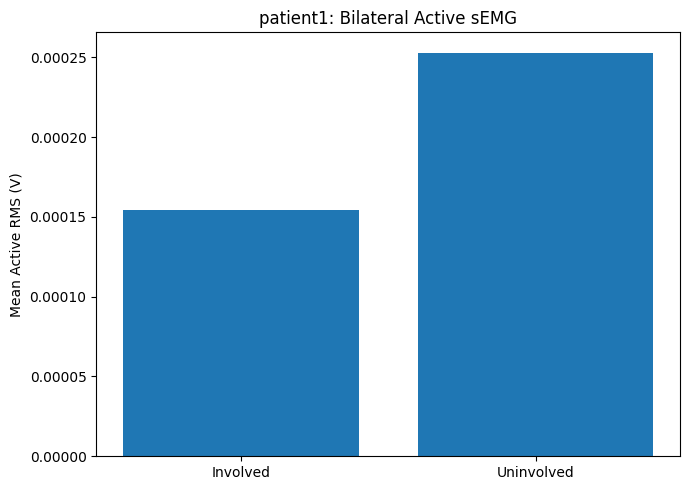

In [28]:
# Cell 12: Visualize involved vs uninvolved activation

participant_id = "patient1"

row = analysis_df[
    analysis_df["Participant"] == participant_id
].iloc[0]

labels = [
    "Involved",
    "Uninvolved"
]

values = [
    row["Involved_RMS"],
    row["Uninvolved_RMS"]
]


fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    labels,
    values
)

ax.set_ylabel("Mean Active RMS (V)")

ax.set_title(
    f"{participant_id}: Bilateral Active sEMG"
)

plt.tight_layout()
plt.show()

In [29]:
# Cell 13: Generate an interpretable participant summary

def generate_interpretation(assessment):

    if assessment["Assessment_Status"] != "Available":

        return (
            f"{assessment['Participant']} cannot be interpreted reliably "
            f"because the recording requires QC review. "
            f"Involved-side QC: {assessment['Involved_QC']}; "
            f"uninvolved-side QC: {assessment['Uninvolved_QC']}."
        )

    participant = assessment["Participant"]

    ratio = assessment["RMS_Ratio"]

    difference = assessment[
        "Activation_Difference_Pct"
    ]

    direction = assessment[
        "Activation_Direction"
    ]

    category = assessment[
        "Reference_Category"
    ]

    score = assessment[
        "Robust_Asymmetry_Score"
    ]

    if direction == "Involved side lower":

        direction_text = (
            f"the involved-side active RMS was approximately "
            f"{difference:.1f}% lower than the uninvolved side"
        )

    elif direction == "Involved side higher":

        direction_text = (
            f"the involved-side active RMS was approximately "
            f"{difference:.1f}% higher than the uninvolved side"
        )

    else:

        direction_text = (
            "bilateral active RMS values were approximately symmetric"
        )

    return (
        f"{participant} demonstrated an RMS ratio of {ratio:.2f}; "
        f"{direction_text}. "
        f"The participant's bilateral asymmetry was classified as "
        f"'{category}' relative to the exploratory healthy reference "
        f"(robust asymmetry score = {score:.2f}). "
        f"This output describes sEMG activation patterns and should not "
        f"be interpreted as a clinical diagnosis or return-to-sport decision."
    )


print(
    generate_interpretation(
        patient1_assessment
    )
)

patient1 demonstrated an RMS ratio of 0.61; the involved-side active RMS was approximately 39.0% lower than the uninvolved side. The participant's bilateral asymmetry was classified as 'Highly elevated' relative to the exploratory healthy reference (robust asymmetry score = 3.47). This output describes sEMG activation patterns and should not be interpreted as a clinical diagnosis or return-to-sport decision.


In [30]:
print(
    generate_interpretation(
        patient12_assessment
    )
)

patient12 cannot be interpreted reliably because the recording requires QC review. Involved-side QC: Review - low contraction count; uninvolved-side QC: Pass.


In [31]:
# Cell 15: Build a reusable participant report function

def generate_patient_report(participant_id):

    assessment = assess_participant(
        participant_id,
        df,
        healthy_reference
    )

    print("=" * 65)
    print(f"PARTICIPANT sEMG ANALYTICS REPORT: {participant_id}")
    print("=" * 65)

    # 后面保持原样

    # ---------------------------------------
    # 2. QC guardrail
    # ---------------------------------------
    if assessment["Assessment_Status"] != "Available":

        print("\nAssessment Status:")
        print(assessment["Assessment_Status"])

        print("\nQC Information:")
        print(
            f"Involved side: {assessment['Involved_QC']}"
        )
        print(
            f"Uninvolved side: {assessment['Uninvolved_QC']}"
        )

        print("\nInterpretation:")
        print(generate_interpretation(assessment))

        return

    # ---------------------------------------
    # 3. Participant profile
    # ---------------------------------------
    print("\nParticipant Profile")
    print("-" * 30)

    display(
        assessment_to_table(assessment)
    )

    # ---------------------------------------
    # 4. Healthy reference visualization
    # ---------------------------------------
    participant_deviation = assessment[
        "Symmetry_Deviation"
    ]

    healthy_values = healthy_df[
        "Symmetry_Deviation"
    ].dropna().to_numpy()

    fig, ax = plt.subplots(figsize=(10, 4))

    # Add small vertical jitter so overlapping
    # healthy-control points remain visible
    rng = np.random.default_rng(42)

    healthy_y = rng.normal(
        loc=0,
        scale=0.025,
        size=len(healthy_values)
    )

    ax.scatter(
        healthy_values,
        healthy_y,
        s=80,
        alpha=0.7,
        label="Healthy controls"
    )

    ax.scatter(
        participant_deviation,
        0,
        s=200,
        marker="*",
        label=participant_id
    )

    ax.axvline(
        healthy_reference[
            "Median_Symmetry_Deviation"
        ],
        linestyle="--",
        linewidth=1.5,
        label="Healthy median"
    )

    ax.set_yticks([])

    ax.set_xlabel(
        "Symmetry Deviation |log(Involved / Uninvolved RMS)|"
    )

    ax.set_title(
        f"{participant_id}: Asymmetry Relative to Healthy Reference"
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

    # ---------------------------------------
    # 5. Bilateral activation visualization
    # ---------------------------------------
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.bar(
        ["Involved", "Uninvolved"],
        [
            assessment["Involved_RMS"],
            assessment["Uninvolved_RMS"]
        ]
    )

    ax.set_ylabel("Mean Active RMS (V)")

    ax.set_title(
        f"{participant_id}: Bilateral Active sEMG"
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------
    # 6. Automated interpretation
    # ---------------------------------------
    print("\nInterpretation")
    print("-" * 30)

    print(
        generate_interpretation(
            assessment
        )
    )

    print("\n" + "=" * 65)

PARTICIPANT sEMG ANALYTICS REPORT: patient1

Participant Profile
------------------------------


,Metric,Value
0,Participant,patient1
1,Assessment Status,Available
2,RMS Ratio,0.610
3,Activation Difference,39.0%
4,Activation Direction,Involved side lower
5,Symmetry Deviation,0.494
6,Robust Asymmetry Score,3.47
7,Reference Category,Highly elevated
8,Valid Involved Contractions,9
9,Valid Uninvolved Contractions,9


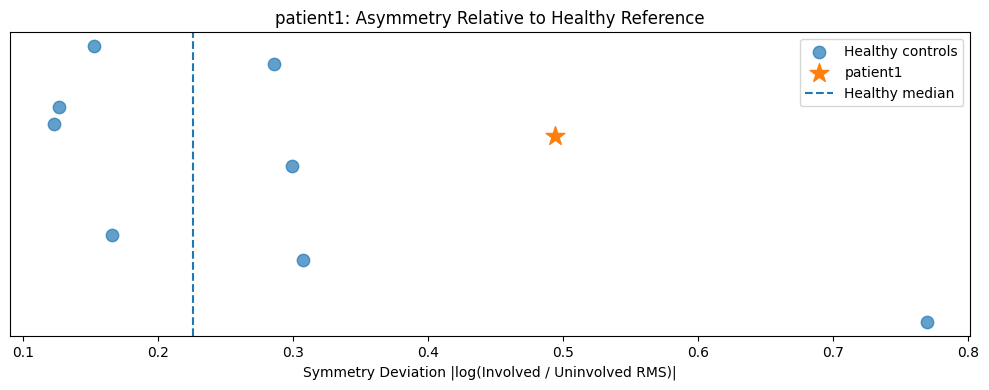

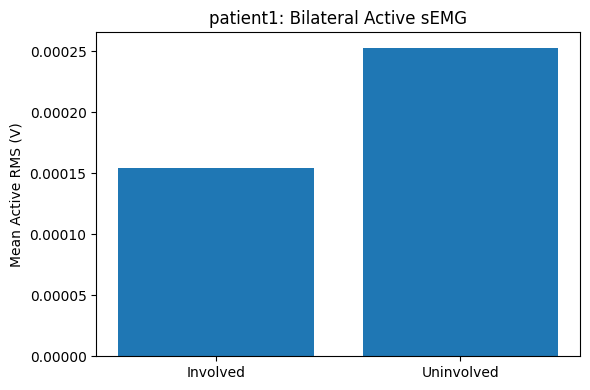


Interpretation
------------------------------
patient1 demonstrated an RMS ratio of 0.61; the involved-side active RMS was approximately 39.0% lower than the uninvolved side. The participant's bilateral asymmetry was classified as 'Highly elevated' relative to the exploratory healthy reference (robust asymmetry score = 3.47). This output describes sEMG activation patterns and should not be interpreted as a clinical diagnosis or return-to-sport decision.



In [32]:
# Cell 16: Test full report on a primary-analysis participant

generate_patient_report("patient1")

In [33]:
# Cell 17: Build ACL cohort screening table

acl_screening = (
    analysis_df[
        analysis_df["Cohort"] == "ACL Patient"
    ][
        [
            "Participant",
            "RMS_Ratio",
            "Symmetry_Deviation",
            "Robust_Asymmetry_Score",
            "Activation_Difference_Pct",
            "Activation_Direction",
            "Asymmetry_Category",
            "Involved_Valid_Contractions",
            "Uninvolved_Valid_Contractions"
        ]
    ]
    .sort_values(
        "Robust_Asymmetry_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    acl_screening.round(3)
)

,Participant,RMS_Ratio,Symmetry_Deviation,Robust_Asymmetry_Score,Activation_Difference_Pct,Activation_Direction,Asymmetry_Category,Involved_Valid_Contractions,Uninvolved_Valid_Contractions
0,patient11,0.583,0.540,4.067,41.736,Involved side lower,Highly elevated,9,9
1,patient1,0.610,0.494,3.472,38.989,Involved side lower,Highly elevated,9,9
2,patient3,0.645,0.439,2.760,35.538,Involved side lower,Highly elevated,8,9
3,patient4,0.705,0.350,1.609,29.531,Involved side lower,Moderately elevated,9,10
4,patient5,1.371,0.315,1.161,37.081,Involved side higher,Moderately elevated,9,9
5,patient7,0.775,0.255,0.381,22.507,Involved side lower,Within reference range,9,9
6,patient2,0.801,0.221,-0.054,19.855,Involved side lower,Within reference range,9,8
7,patient9,1.174,0.160,-0.842,17.401,Involved side higher,Within reference range,9,9
8,patient10,0.893,0.113,-1.455,10.683,Involved side lower,Within reference range,8,9
9,patient8,1.097,0.092,-1.721,9.677,Approximately symmetric,Within reference range,9,9


In [34]:
# Cell 18: Add exploratory review priority

def assign_review_priority(row):

    score = row["Robust_Asymmetry_Score"]

    if score > 2:
        return "High review priority"

    elif score > 1:
        return "Moderate review priority"

    else:
        return "Routine review"


acl_screening["Review_Priority"] = (
    acl_screening.apply(
        assign_review_priority,
        axis=1
    )
)

display(
    acl_screening[
        [
            "Participant",
            "RMS_Ratio",
            "Activation_Direction",
            "Robust_Asymmetry_Score",
            "Review_Priority"
        ]
    ]
)

,Participant,RMS_Ratio,Activation_Direction,Robust_Asymmetry_Score,Review_Priority
0,patient11,0.582636,Involved side lower,4.066965,High review priority
1,patient1,0.610105,Involved side lower,3.471508,High review priority
2,patient3,0.644618,Involved side lower,2.760289,High review priority
3,patient4,0.704690,Involved side lower,1.608650,Moderate review priority
4,patient5,1.370808,Involved side higher,1.161473,Moderate review priority
5,patient7,0.774933,Involved side lower,0.380502,Routine review
6,patient2,0.801447,Involved side lower,-0.054329,Routine review
7,patient9,1.174006,Involved side higher,-0.841661,Routine review
8,patient10,0.893173,Involved side lower,-1.454920,Routine review
9,patient8,1.096771,Approximately symmetric,-1.721237,Routine review


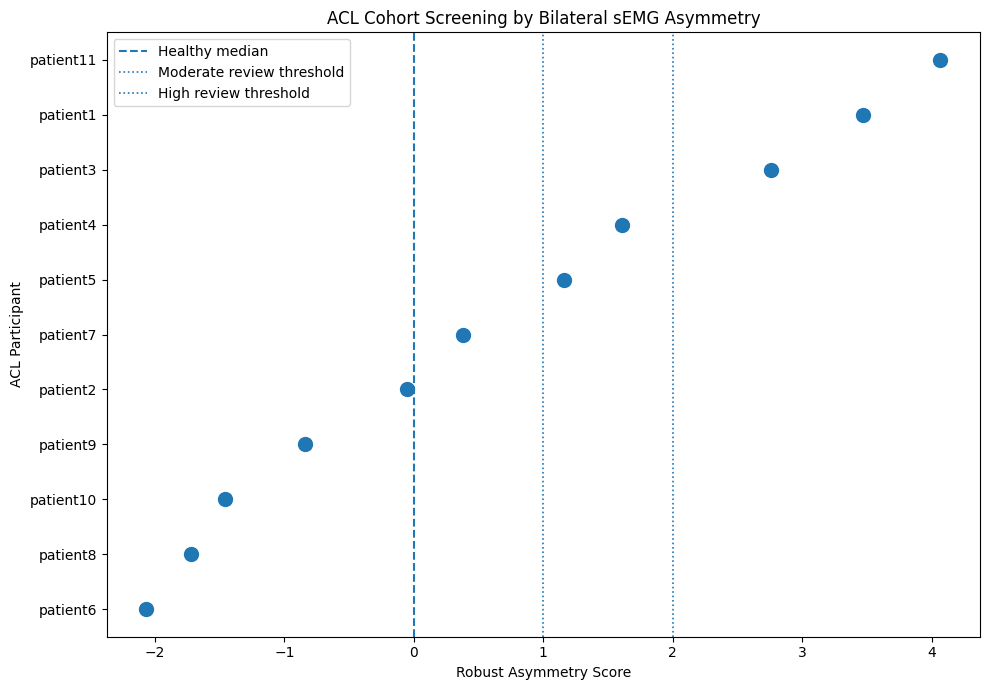

In [35]:
# Cell 19: Visualize ACL participants by review priority

plot_df = acl_screening.sort_values(
    "Robust_Asymmetry_Score",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

y = np.arange(len(plot_df))

ax.scatter(
    plot_df["Robust_Asymmetry_Score"],
    y,
    s=100
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Healthy median"
)

ax.axvline(
    1,
    linestyle=":",
    linewidth=1.2,
    label="Moderate review threshold"
)

ax.axvline(
    2,
    linestyle=":",
    linewidth=1.2,
    label="High review threshold"
)

ax.set_yticks(y)
ax.set_yticklabels(
    plot_df["Participant"]
)

ax.set_xlabel(
    "Robust Asymmetry Score"
)

ax.set_ylabel(
    "ACL Participant"
)

ax.set_title(
    "ACL Cohort Screening by Bilateral sEMG Asymmetry"
)

ax.legend()

plt.tight_layout()
plt.show()

In [36]:
# Cell 20: Summarize ACL screening priorities

priority_summary = (
    acl_screening["Review_Priority"]
    .value_counts()
    .rename_axis("Review_Priority")
    .reset_index(name="Participants")
)

display(priority_summary)

print("\nActivation direction:")
print(
    acl_screening[
        "Activation_Direction"
    ].value_counts()
)

,Review_Priority,Participants
0,Routine review,6
1,High review priority,3
2,Moderate review priority,2



Activation direction:
Activation_Direction
Involved side lower        7
Involved side higher       2
Approximately symmetric    2
Name: count, dtype: int64


In [37]:
# Cell 21: Identify participants for additional review

participants_for_review = acl_screening[
    acl_screening["Review_Priority"].isin(
        [
            "High review priority",
            "Moderate review priority"
        ]
    )
].copy()

print(
    "Participants flagged for additional analytical review:",
    len(participants_for_review)
)

display(
    participants_for_review[
        [
            "Participant",
            "RMS_Ratio",
            "Activation_Difference_Pct",
            "Activation_Direction",
            "Robust_Asymmetry_Score",
            "Review_Priority"
        ]
    ].round(3)
)

Participants flagged for additional analytical review: 5


,Participant,RMS_Ratio,Activation_Difference_Pct,Activation_Direction,Robust_Asymmetry_Score,Review_Priority
0,patient11,0.583,41.736,Involved side lower,4.067,High review priority
1,patient1,0.610,38.989,Involved side lower,3.472,High review priority
2,patient3,0.645,35.538,Involved side lower,2.760,High review priority
3,patient4,0.705,29.531,Involved side lower,1.609,Moderate review priority
4,patient5,1.371,37.081,Involved side higher,1.161,Moderate review priority


In [38]:
# Cell 22: Cohort-level ACL analytics dashboard

def generate_cohort_dashboard():

    acl = acl_screening.copy()

    print("=" * 70)
    print("ACL REHABILITATION sEMG ANALYTICS DASHBOARD")
    print("=" * 70)

    print(f"\nParticipants analyzed: {len(acl)}")

    print("\nReview Priority Summary")
    print("-" * 30)

    priority_order = [
        "High review priority",
        "Moderate review priority",
        "Routine review"
    ]

    for priority in priority_order:
        n = (acl["Review_Priority"] == priority).sum()
        print(f"{priority}: {n}")

    print("\nActivation Direction Summary")
    print("-" * 30)

    print(
        acl["Activation_Direction"]
        .value_counts()
        .to_string()
    )

    # -----------------------------------------
    # Plot 1: Robust asymmetry score
    # -----------------------------------------

    plot_df = acl.sort_values(
        "Robust_Asymmetry_Score"
    )

    fig, ax = plt.subplots(figsize=(10, 7))

    y = np.arange(len(plot_df))

    ax.scatter(
        plot_df["Robust_Asymmetry_Score"],
        y,
        s=100
    )

    ax.axvline(
        0,
        linestyle="--",
        label="Healthy median"
    )

    ax.axvline(
        1,
        linestyle=":",
        label="Moderate review threshold"
    )

    ax.axvline(
        2,
        linestyle=":",
        label="High review threshold"
    )

    ax.set_yticks(y)
    ax.set_yticklabels(
        plot_df["Participant"]
    )

    ax.set_xlabel(
        "Robust Asymmetry Score (MAD units)"
    )

    ax.set_ylabel(
        "ACL Participant"
    )

    ax.set_title(
        "ACL Participants Relative to Healthy Reference"
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

    # -----------------------------------------
    # Plot 2: Directional RMS ratio
    # -----------------------------------------

    ratio_df = acl.sort_values(
        "RMS_Ratio"
    )

    fig, ax = plt.subplots(figsize=(10, 7))

    y = np.arange(len(ratio_df))

    ax.scatter(
        ratio_df["RMS_Ratio"],
        y,
        s=100
    )

    ax.axvline(
        1,
        linestyle="--",
        label="Equal bilateral activation"
    )

    ax.axvspan(
        0.9,
        1.1,
        alpha=0.15,
        label="±10% exploratory symmetry band"
    )

    ax.set_yticks(y)
    ax.set_yticklabels(
        ratio_df["Participant"]
    )

    ax.set_xlabel(
        "Involved / Uninvolved Active RMS Ratio"
    )

    ax.set_ylabel(
        "ACL Participant"
    )

    ax.set_title(
        "Direction of Bilateral Muscle Activation Difference"
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

    # -----------------------------------------
    # Participants requiring review
    # -----------------------------------------

    flagged = acl[
        acl["Review_Priority"] != "Routine review"
    ].copy()

    print("\nParticipants Flagged for Additional Analytical Review")
    print("-" * 55)

    display(
        flagged[
            [
                "Participant",
                "RMS_Ratio",
                "Activation_Difference_Pct",
                "Activation_Direction",
                "Robust_Asymmetry_Score",
                "Review_Priority"
            ]
        ].round(3)
    )

ACL REHABILITATION sEMG ANALYTICS DASHBOARD

Participants analyzed: 11

Review Priority Summary
------------------------------
High review priority: 3
Moderate review priority: 2
Routine review: 6

Activation Direction Summary
------------------------------
Activation_Direction
Involved side lower        7
Involved side higher       2
Approximately symmetric    2


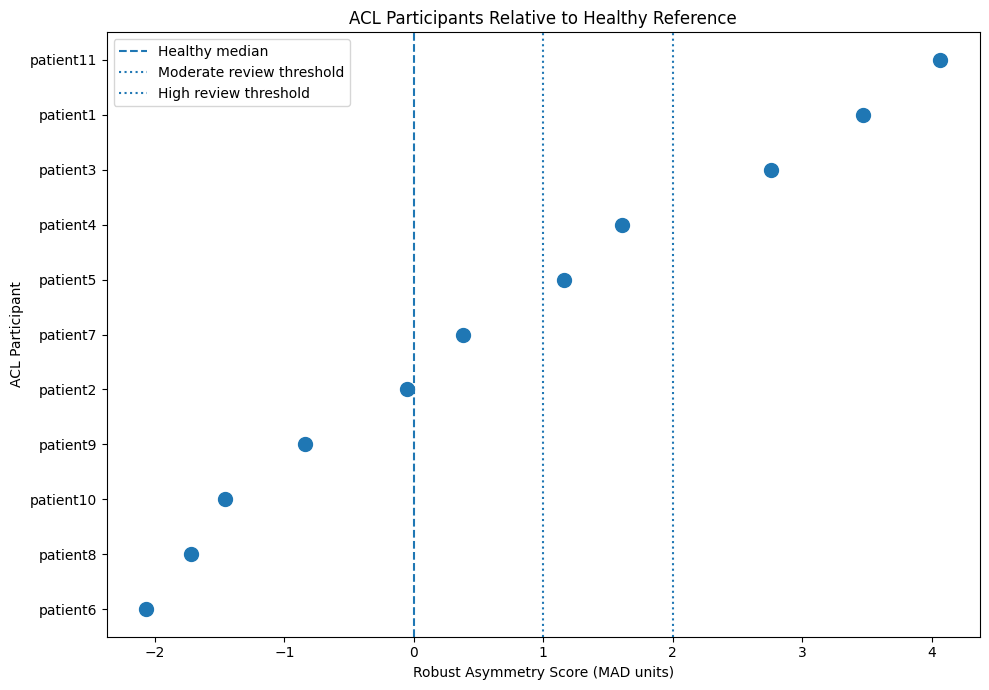

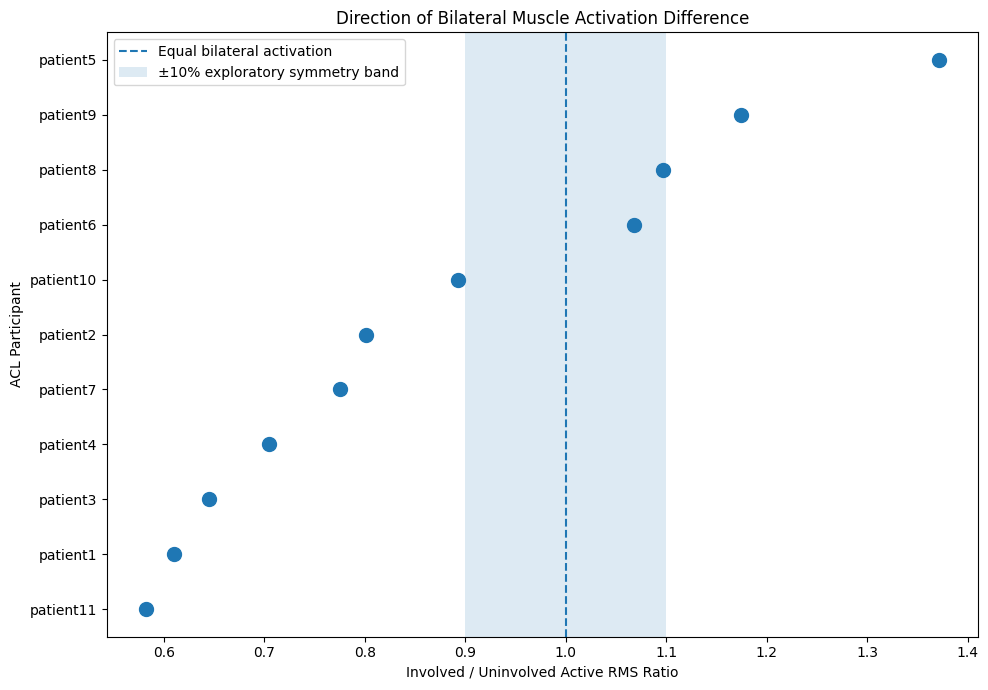


Participants Flagged for Additional Analytical Review
-------------------------------------------------------


,Participant,RMS_Ratio,Activation_Difference_Pct,Activation_Direction,Robust_Asymmetry_Score,Review_Priority
0,patient11,0.583,41.736,Involved side lower,4.067,High review priority
1,patient1,0.610,38.989,Involved side lower,3.472,High review priority
2,patient3,0.645,35.538,Involved side lower,2.760,High review priority
3,patient4,0.705,29.531,Involved side lower,1.609,Moderate review priority
4,patient5,1.371,37.081,Involved side higher,1.161,Moderate review priority


In [39]:
# Cell 23: Generate cohort dashboard

generate_cohort_dashboard()

PARTICIPANT sEMG ANALYTICS REPORT: patient11

Participant Profile
------------------------------


,Metric,Value
0,Participant,patient11
1,Assessment Status,Available
2,RMS Ratio,0.583
3,Activation Difference,41.7%
4,Activation Direction,Involved side lower
5,Symmetry Deviation,0.540
6,Robust Asymmetry Score,4.07
7,Reference Category,Highly elevated
8,Valid Involved Contractions,9
9,Valid Uninvolved Contractions,9


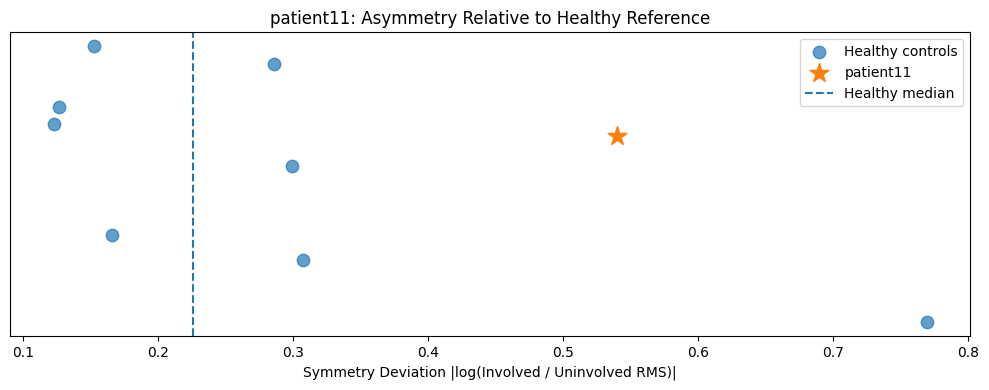

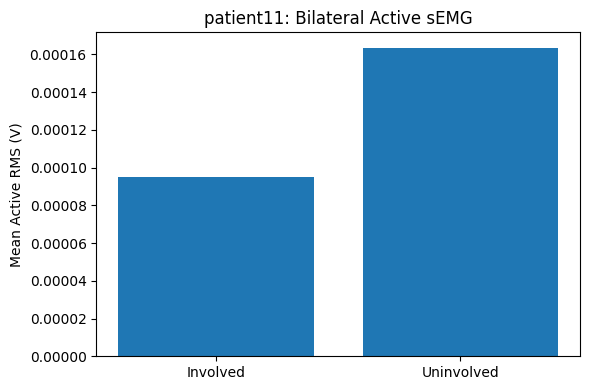


Interpretation
------------------------------
patient11 demonstrated an RMS ratio of 0.58; the involved-side active RMS was approximately 41.7% lower than the uninvolved side. The participant's bilateral asymmetry was classified as 'Highly elevated' relative to the exploratory healthy reference (robust asymmetry score = 4.07). This output describes sEMG activation patterns and should not be interpreted as a clinical diagnosis or return-to-sport decision.



In [40]:
# Cell 24: Review a flagged participant

participant_to_review = "patient11"

generate_patient_report(
    participant_to_review
)